# Grid x CCS test matrix — results

Four IAM grids (REMIND, MESSAGE, AIM, WITCH) crossed with four captive-power capture
regimes (unlimited, none, low, high). Smelter side, MPP-flat demand, budget = 2020
smelting emissions declining linearly to 5% by 2050.

Emissions are `CO2 Scope1 + CO2 Scope2` as reported (both already net of deployed capture;
the separate `CO2 Scope1 captured` column is a per-tonne input factor, not realised capture,
so it is not used here). Budget is each run's own `carbon_budget.csv` (identical across cells).
Reads the saved runs directly, independent of `common.py`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RUNS = Path("..") / ".." / "runs"          # notebooks/analysis -> scenarios/runs
GRIDS = ["REMIND", "MESSAGE", "AIM", "WITCH"]
CCS   = ["unlimited", "none", "low", "high"]
YEARS = range(2020, 2051)

def interface(cell):
    f = next((RUNS / cell / "smelter" / "final").glob("interface_outputs_*.csv"))
    return pd.read_csv(f)

def annual_emissions(cell):
    d = interface(cell)
    e = d[d.parameter.isin(["CO2 Scope1", "CO2 Scope2"])]
    return e.groupby("year").value.sum()          # Mt CO2/yr

def budget(cell):                                  # Gt CO2/yr, indexed by year
    b = pd.read_csv(RUNS / cell / "smelter" / "inputs_used" / "carbon_budget.csv")
    return b.set_index("year").annual_limit

def mix_2050(cell):                                # Mt by power source in 2050
    d = interface(cell)
    v = d[(d.parameter == "Annual production volume") & (d.year == 2050)].copy()
    v = v[v.technology.astype(str).str.contains(" + ", regex=False)]
    v["power"] = v.technology.astype(str).str.split(" + ", n=1, regex=False).str[1]
    v["anode"] = v.technology.astype(str).str.split(" + ", n=1, regex=False).str[0]
    return v

print("runs found:", sum((RUNS / f"{g}_{c}").exists() for g in GRIDS for c in CCS), "of 16")

runs found: 16 of 16


## 1. Cumulative emissions and gap to budget

In [2]:
rows = []
for g in GRIDS:
    for c in CCS:
        cell = f"{g}_{c}"
        cum = annual_emissions(cell).loc[2020:2050].sum() / 1000     # Mt -> Gt
        bcum = budget(cell).loc[2020:2050].sum()                     # Gt
        rows.append(dict(grid=g, ccs=c, cum_Gt=cum, budget_Gt=bcum,
                         gap_Gt=cum - bcum, gap_pct=100 * (cum - bcum) / bcum))
summary = pd.DataFrame(rows)

cum_tab = summary.pivot(index="grid", columns="ccs", values="cum_Gt").reindex(GRIDS, columns=CCS)
gap_tab = summary.pivot(index="grid", columns="ccs", values="gap_pct").reindex(GRIDS, columns=CCS)
print("Cumulative emissions 2020-2050 (Gt), budget = %.2f Gt\n" % summary.budget_Gt.iloc[0])
display(cum_tab.round(2))
print("\nGap to budget (%)")
display(gap_tab.round(1))

Cumulative emissions 2020-2050 (Gt), budget = 12.75 Gt



ccs,unlimited,none,low,high
grid,,,,
REMIND,12.71,12.55,12.55,12.67
MESSAGE,12.65,12.51,12.55,12.60
AIM,12.75,12.55,12.63,12.67
WITCH,12.44,12.34,12.37,12.25



Gap to budget (%)


ccs,unlimited,none,low,high
grid,,,,
REMIND,-0.3,-1.6,-1.6,-0.6
MESSAGE,-0.8,-1.9,-1.6,-1.2
AIM,-0.0,-1.6,-0.9,-0.6
WITCH,-2.4,-3.2,-3.0,-3.9


Read across a row for the capture effect at a fixed grid, down a column for the grid effect
at a fixed capture regime. Every cell lands within a few percent of the budget under MPP-flat
demand — the weak feasibility gradient discussed in the design notes.

## 2. Annual emissions against the budget

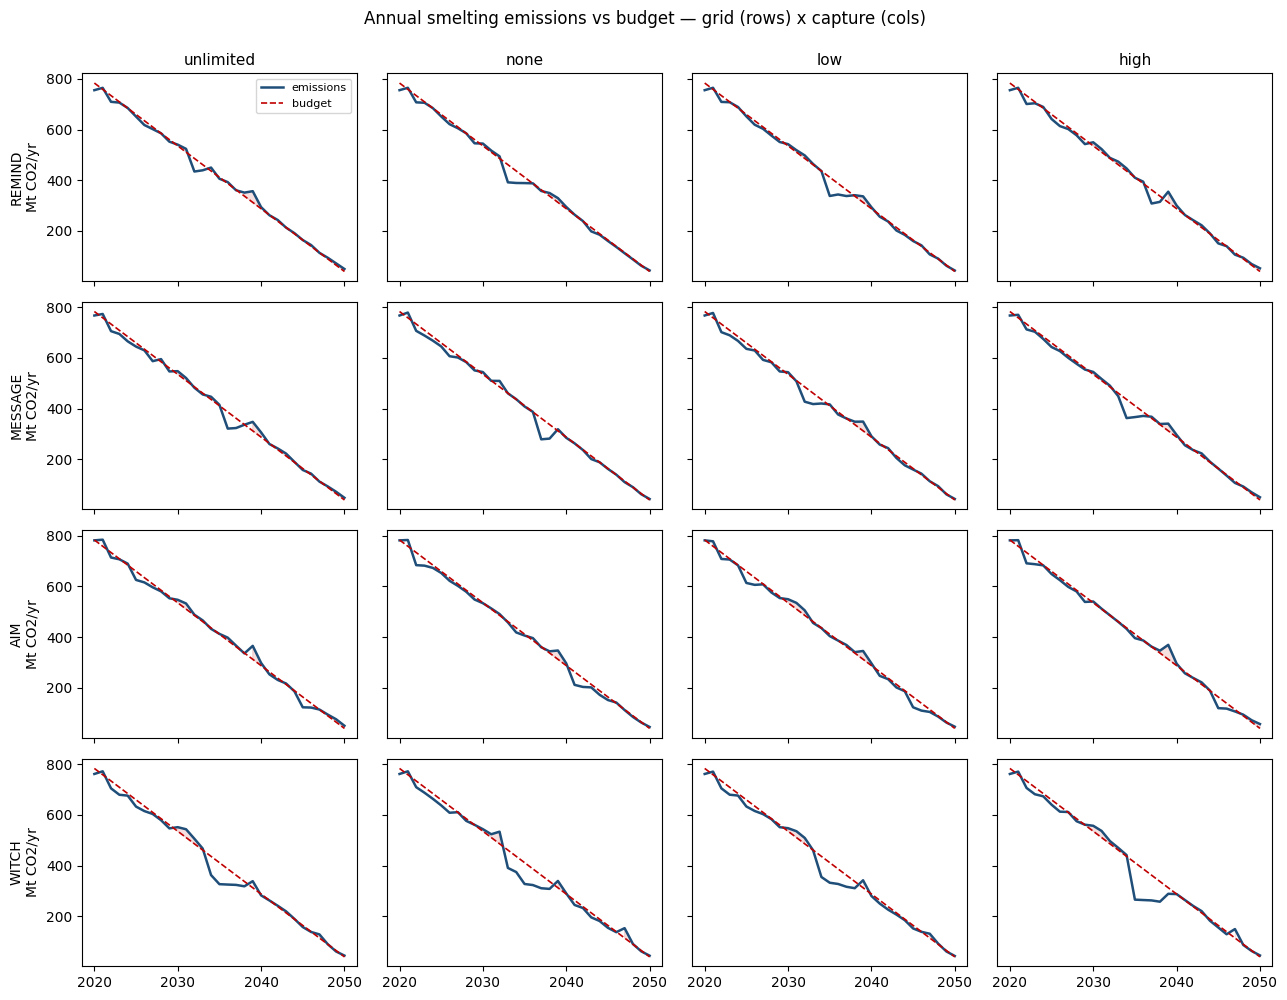

In [3]:
fig, axes = plt.subplots(len(GRIDS), len(CCS), figsize=(13, 10), sharex=True, sharey=True)
yrs = list(YEARS)
for i, g in enumerate(GRIDS):
    for j, c in enumerate(CCS):
        ax = axes[i][j]
        cell = f"{g}_{c}"
        e = annual_emissions(cell).reindex(yrs)
        b = budget(cell).reindex(yrs) * 1000                        # Gt -> Mt
        ax.plot(yrs, e.values, color="#1f4e79", lw=1.8, label="emissions")
        ax.plot(yrs, b.values, color="#c00000", lw=1.2, ls="--", label="budget")
        ax.fill_between(yrs, b.values, e.values, where=(e.values > b.values),
                        color="#c00000", alpha=0.12)
        if i == 0: ax.set_title(c, fontsize=11)
        if j == 0: ax.set_ylabel(g + "\nMt CO2/yr", fontsize=10)
axes[0][0].legend(fontsize=8, loc="upper right")
fig.suptitle("Annual smelting emissions vs budget — grid (rows) x capture (cols)", y=0.995)
fig.tight_layout(); plt.show()

## 3. 2050 power-source mix

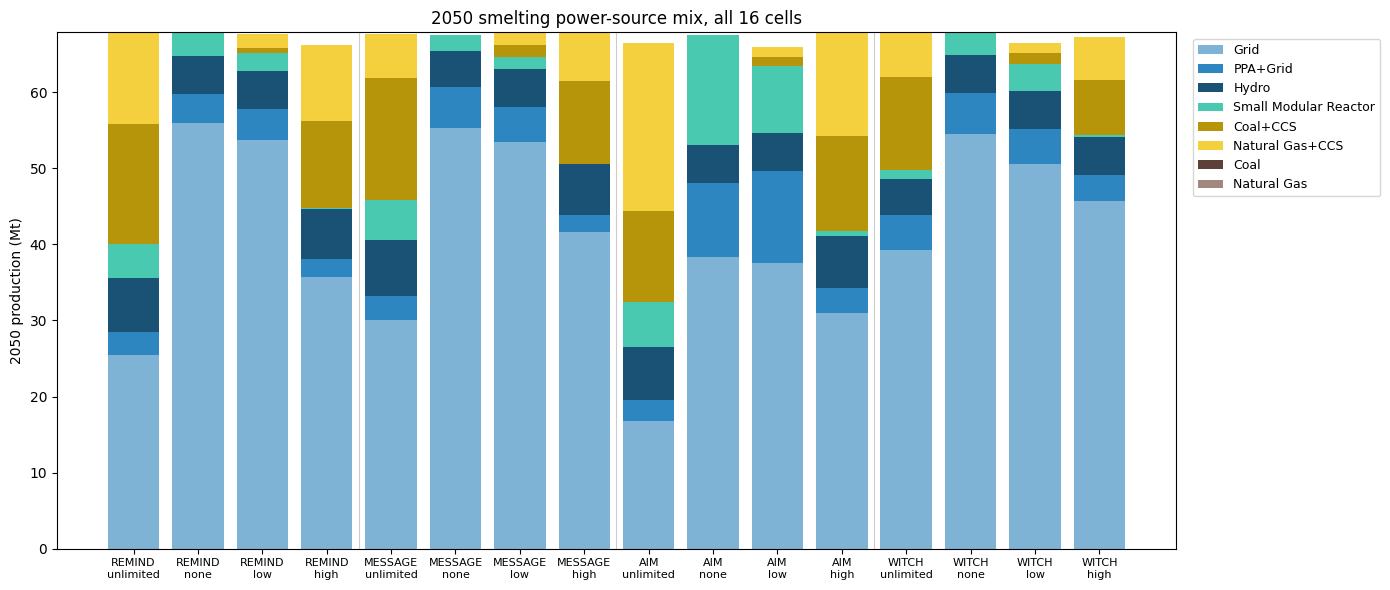

In [4]:
# Order power sources: clean captive, then power-CCS, then unabated fossil
ORDER = ["Grid", "PPA+Grid", "Hydro", "Small Modular Reactor",
         "Coal+CCS", "Natural Gas+CCS", "Coal", "Natural Gas"]
COLORS = {"Grid": "#7fb3d5", "PPA+Grid": "#2e86c1", "Hydro": "#1a5276",
          "Small Modular Reactor": "#48c9b0", "Coal+CCS": "#b7950b",
          "Natural Gas+CCS": "#f4d03f", "Coal": "#5d4037", "Natural Gas": "#a1887f"}

data = {}
for g in GRIDS:
    for c in CCS:
        m = mix_2050(f"{g}_{c}").groupby("power").value.sum()
        data[f"{g}\n{c}"] = m
mix = pd.DataFrame(data).reindex(ORDER).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(mix.shape[1])
for p in ORDER:
    ax.bar(mix.columns, mix.loc[p].values, bottom=bottom, label=p, color=COLORS.get(p))
    bottom += mix.loc[p].values
ax.set_ylabel("2050 production (Mt)")
ax.set_title("2050 smelting power-source mix, all 16 cells")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
for x in (3.5, 7.5, 11.5): ax.axvline(x, color="0.8", lw=0.8)
plt.xticks(rotation=0, fontsize=8); fig.tight_layout(); plt.show()

In [5]:
# Category summary: inert-anode share, clean-power Mt, power-CCS Mt, unabated captive-fossil Mt
def cats(cell):
    v = mix_2050(cell); tot = v.value.sum()
    inert = v[v.anode.str.startswith("Inert")].value.sum()
    clean = v[v.power.isin(["Grid", "PPA+Grid", "Hydro", "Small Modular Reactor"])].value.sum()
    ccsp  = v[v.power.str.contains("CCS")].value.sum()
    fossil = v[v.power.isin(["Coal", "Natural Gas"])].value.sum()
    return dict(inert_anode_pct=round(100 * inert / tot), clean_Mt=round(clean, 1),
                power_CCS_Mt=round(ccsp, 1), unabated_fossil_Mt=round(fossil, 1))
cat = pd.DataFrame({f"{g}_{c}": cats(f"{g}_{c}") for g in GRIDS for c in CCS}).T
display(cat)

,inert_anode_pct,clean_Mt,power_CCS_Mt,unabated_fossil_Mt
REMIND_unlimited,94.0,40.1,27.6,0.0
REMIND_none,79.0,67.7,0.0,0.0
REMIND_low,81.0,65.2,2.4,0.0
REMIND_high,87.0,44.8,21.4,0.0
MESSAGE_unlimited,89.0,45.8,21.8,0.0
MESSAGE_none,72.0,67.5,0.0,0.0
MESSAGE_low,75.0,64.6,3.2,0.0
MESSAGE_high,82.0,50.5,17.3,0.0
AIM_unlimited,94.0,32.4,34.0,0.0
AIM_none,78.0,67.5,0.0,0.0
